In [1]:
#MDN predictions from Rrs compared against co-located truth values from a CSV

In [2]:
# Import the base python packages needed for this notebook
import numpy                                                          as np
import scipy
import os
import pandas as pd

import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile

%matplotlib inline
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
# Get the parent directory path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Insert it at the beginning of the path list so Python checks it first
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import get_sensor_bands, get_tile_data
from   MDN                        import current_support 
from   MDN                        import get_gloria_trainTestData, get_args
from   MDN                        import get_spectral_preds
from   MDN                        import create_scatterplots_trueVsPred, performance
from   MDN                        import OC, resample_Rrs, load_water_quality_csv

'Print all the product/sensor model combinations available in the current MDN tool box'
### need to modify this function to only print sensor and product combinations that are available in the current MDN tool box
current_support()

# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend_fallback', 'interactive'])
OLI: predicts chl,tss,cdom
OLCI: predicts chl,tss,cdom
MSI: predicts chl,tss,cdom
HICO: predicts aph,chl,tss,pc,ad,ag,cdom
PRISMA: predicts aph,chl,tss,pc,ad,ag,cdom
PACE-delivery: predicts aph,chl,tss,pc,ad,ag,cdom
VI: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667
MOD: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667
MERIS: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667


In [3]:
#writes Rrs and WQ_data csvs from GLORIA data, remove if using your own data. 

gloria_folder = Path().cwd() / 'data/GLORIA_2022/'

assert gloria_folder.is_dir(), f"No folder found art {gloria_folder}"

# Set the sensor we want to work with
sensor = "HYPER"
products = "chl,tss"

# Get the GLORIA data at the resolution of the OLCI sensor
x_data, y_data, gid_data = get_gloria_trainTestData(sensor=sensor, out_var=products.split(','),
                                                    save_flag=False, load_exists=False,rand_seed=42,
                                                    rem_flagged=True, gloria_folder=gloria_folder,
                                                    flag_name='GLORIA_qc_flags.csv', rrs_name='GLORIA_Rrs.csv',
                                                    bg_name='GLORIA_meta_and_lab.csv', gloria_only=True,
                                                    train_mode=False)


headers = [float(i) for i in range(400, 799)]
# Create the DataFrame and export
n=7517
x_data_ = pd.DataFrame(x_data[0:n,:], columns=headers,index=None)
x_data_.to_csv("Rrs.csv", index=False)

headers = ['chl','tss']
# Create the DataFrame and export
y_data_ = pd.DataFrame(y_data[0:n,:], columns=headers,index=None)
y_data_.to_csv("WQ_data.csv", index=False)

Bands with responses outside of range [350, 899]: 
 []

Creating data for bands
 [np.float64(400.0), np.float64(401.0), np.float64(402.0), np.float64(403.0), np.float64(404.0), np.float64(405.0), np.float64(406.0), np.float64(407.0), np.float64(408.0), np.float64(409.0), np.float64(410.0), np.float64(411.0), np.float64(412.0), np.float64(413.0), np.float64(414.0), np.float64(415.0), np.float64(416.0), np.float64(417.0), np.float64(418.0), np.float64(419.0), np.float64(420.0), np.float64(421.0), np.float64(422.0), np.float64(423.0), np.float64(424.0), np.float64(425.0), np.float64(426.0), np.float64(427.0), np.float64(428.0), np.float64(429.0), np.float64(430.0), np.float64(431.0), np.float64(432.0), np.float64(433.0), np.float64(434.0), np.float64(435.0), np.float64(436.0), np.float64(437.0), np.float64(438.0), np.float64(439.0), np.float64(440.0), np.float64(441.0), np.float64(442.0), np.float64(443.0), np.float64(444.0), np.float64(445.0), np.float64(446.0), np.float64(447.0), np.flo

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7572/7572 [00:21<00:00, 351.31it/s]


Loaded 7517 spectra across 399 wavelengths.
Wavelength range: 400.0 to 798.0
Bands with responses outside of range [400.0, 798.0]: 
 [np.float64(400.0), np.float64(865.0), np.float64(885.0), np.float64(900.0), np.float64(940.0), np.float64(1020.0)]

Creating data for bands
 [np.float64(412.5), np.float64(442.5), np.float64(490.0), np.float64(510.0), np.float64(560.0), np.float64(620.0), np.float64(665.0), np.float64(673.75), np.float64(681.25), np.float64(708.75), np.float64(753.75), np.float64(761.25), np.float64(764.375), np.float64(767.5), np.float64(778.75)]


Processing MDN ensemble for uncertainty: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 11.40it/s]


chl:            MdSA: 27.293   SSPB: -1.922   Slope:  0.899   MSA: 50.505   RMSLE:  0.650   MAE: 20.001   <=0NaN:  0.000
tss:            MdSA: 34.339   SSPB:  1.187   Slope:  0.668   MSA: 76.526   RMSLE:  0.914   MAE: 15.378   <=0NaN:  0.000


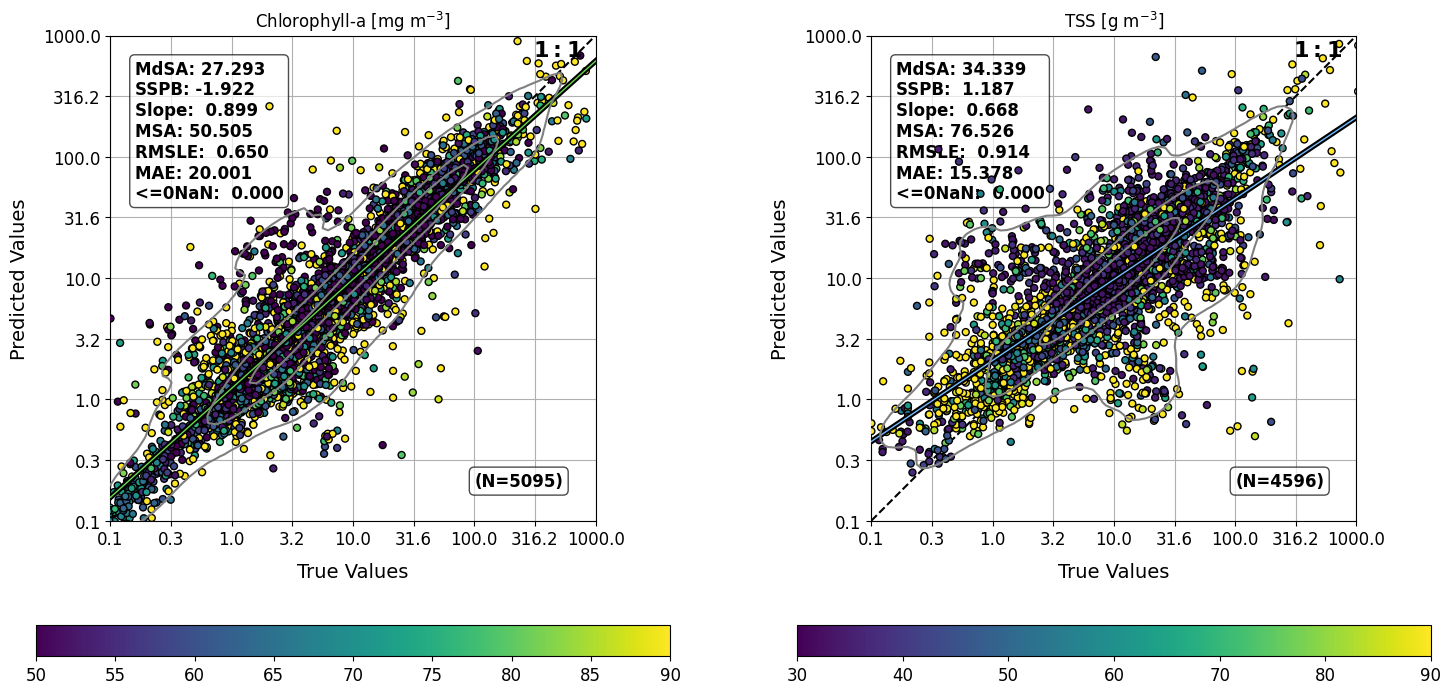

In [4]:
# User modifiable
sensor   = "OLCI"
products = "chl,tss"

# 1. Load the CSV file
df        = pd.read_csv('Rrs.csv', header=None)
true_data = load_water_quality_csv('WQ_data.csv')

#########################################################################################
true_data = np.array([true_data[product].values for product in products.split(',')]).T

# 2. Extract wavelengths from the first row (excluding the first column label if necessary)
# If your first column is sample names, start from index 1.
wavelengths = df.iloc[0, :].astype(float).values 

rrs_data    = df.iloc[1:, :].astype(float).values  # Grid of intensity/absorbance values

print(f"Loaded {len(rrs_data)} spectra across {len(wavelengths)} wavelengths.")
print("Wavelength range:", wavelengths.min(), "to", wavelengths.max())

rrs_data_resampled, wavelengths_resampled = resample_Rrs(sensor=sensor,rrs_data=rrs_data,wvl_in=wavelengths)

# Get the predictions for the GLORIA data using the MDN model for OLCI sensor
wq_estimates, wq_uncert, wq_selected_slices =get_spectral_preds(test_x=rrs_data_resampled, op_mode="select", sensor=sensor, products= products, return_uncert= "True", 
                                                uncert_mode= "limits", scaler_mode = "invert", progress_vis= True)

'Compare the true and predicted values and get a set of regression metrics'
inp_str = []
for key in wq_selected_slices:
    str1 = (performance(f'', true_data[:, wq_selected_slices[key]], np.squeeze(wq_estimates['pred'][0, :, wq_selected_slices[key]])).replace('|', ''))
    inp_str += [str1.replace('   ', '\n')]
    print(f"{key}:{str1}")

# Also get the uncertainty as a percentage of the predicted value
uncert_perc = ((wq_uncert['high_lim'] - wq_uncert['low_lim']) / wq_estimates['pred']) * 100

%matplotlib inline
'Show a graphical comparision of the true and predicted values'
fig1 = create_scatterplots_trueVsPred(true_data, np.squeeze(wq_estimates['pred']), color=np.squeeze(uncert_perc), short_name=[r'Chlorophyll-a [$mg~m^{-3}$]', r'TSS [$g~m^{-3}$]'], 
                            x_label=['True Values', 'True Values'], y_label=['Predicted Values', 'Predicted Values'], inplot_str=inp_str,
                            title="", maxv_b=[3, 3], minv_b=[-1, -1], ipython_mode=True, vmin_b=[50., 30.], vmax_b=[90., 90.])